### Customer Shopping Behaviour Analysis Project 

import Liabraries 

In [1]:
import pandas as pd 
import numpy as np 

Import data 

In [2]:
df = pd.read_csv(r'C:\Users\lenovo\Downloads\customer_shopping_behavior.csv')

In [3]:
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,Yes,31,PayPal,Annually


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3900 entries, 0 to 3899
Data columns (total 18 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Customer ID             3900 non-null   int64  
 1   Age                     3900 non-null   int64  
 2   Gender                  3900 non-null   object 
 3   Item Purchased          3900 non-null   object 
 4   Category                3900 non-null   object 
 5   Purchase Amount (USD)   3900 non-null   int64  
 6   Location                3900 non-null   object 
 7   Size                    3900 non-null   object 
 8   Color                   3900 non-null   object 
 9   Season                  3900 non-null   object 
 10  Review Rating           3863 non-null   float64
 11  Subscription Status     3900 non-null   object 
 12  Shipping Type           3900 non-null   object 
 13  Discount Applied        3900 non-null   object 
 14  Promo Code Used         3900 non-null   

In [5]:
df.describe() # to get the statical view of data

,Customer ID,Age,Purchase Amount (USD),Review Rating,Previous Purchases
count,3900.000000,3900.000000,3900.000000,3863.000000,3900.000000
mean,1950.500000,44.068462,59.764359,3.750065,25.351538
std,1125.977353,15.207589,23.685392,0.716983,14.447125
min,1.000000,18.000000,20.000000,2.500000,1.000000
25%,975.750000,31.000000,39.000000,3.100000,13.000000
50%,1950.500000,44.000000,60.000000,3.800000,25.000000
75%,2925.250000,57.000000,81.000000,4.400000,38.000000
max,3900.000000,70.000000,100.000000,5.000000,50.000000


In [6]:
# check the null values 
df.isnull().sum()

Customer ID                0
Age                        0
Gender                     0
Item Purchased             0
Category                   0
Purchase Amount (USD)      0
Location                   0
Size                       0
Color                      0
Season                     0
Review Rating             37
Subscription Status        0
Shipping Type              0
Discount Applied           0
Promo Code Used            0
Previous Purchases         0
Payment Method             0
Frequency of Purchases     0
dtype: int64

fill the missing values of Review Rating with median of product categories.

In [5]:
df['Review Rating'] = df.groupby('Category')['Review Rating'].transform(lambda x: x.fillna(x.median()))

In [6]:
df.isnull().sum()

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Shipping Type             0
Discount Applied          0
Promo Code Used           0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64

In [7]:
# to check the goods categories in the category column 
df['Category'].value_counts()

Category
Clothing       1737
Accessories    1240
Footwear        599
Outerwear       324
Name: count, dtype: int64

Remove the spaces of column name and change into lower case

In [4]:
df.columns = df.columns.str.lower()
df.columns = df.columns.str.replace(' ','_') 
df = df.rename(columns={'purchase_amount_(usd)':'purchase_amount'})

In [9]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'promo_code_used', 'previous_purchases',
       'payment_method', 'frequency_of_purchases'],
      dtype='object')

### Feature Engineering 
create a new column age_group

In [10]:
labels = ['Young Adult','Adult','Middle_aged','Senior']
df['age_group'] = pd.qcut(df['age'],q=4,labels=labels)

In [11]:
df[['age','age_group']].head(10)

,age,age_group
0,55,Middle_aged
1,19,Young Adult
2,50,Middle_aged
3,21,Young Adult
4,45,Middle_aged
5,46,Middle_aged
6,63,Senior
7,27,Young Adult
8,26,Young Adult
9,57,Middle_aged


In [21]:
df['age_group'].value_counts()

age_group
Young Adult    1028
Middle_aged     986
Senior          944
Adult           942
Name: count, dtype: int64

young Adult customers are max in number

In [12]:
# create column purchase_frequency_days,change the categorical data into numbers  

frequency_mapping = {
    'Fortnightly' : 14, 
    'Weekly' : 7,
    'Monthly' :30,
    'Bi-Weekly':14,
    'Annually' : 365, 
    'Every 3 Months':90
}
df['purchase_frequency_days'] = df['frequency_of_purchases'].map(frequency_mapping)


In [23]:
df['frequency_of_purchases'].unique()

array(['Fortnightly', 'Weekly', 'Annually', 'Quarterly', 'Bi-Weekly',
       'Monthly', 'Every 3 Months'], dtype=object)

In [13]:
df[['purchase_frequency_days','frequency_of_purchases']].head(10)

,purchase_frequency_days,frequency_of_purchases
0,14.0,Fortnightly
1,14.0,Fortnightly
2,7.0,Weekly
3,7.0,Weekly
4,365.0,Annually
5,7.0,Weekly
6,NaN,Quarterly
7,7.0,Weekly
8,365.0,Annually
9,NaN,Quarterly


In [14]:
df['frequency_of_purchases'].isna().sum()

np.int64(0)

In [15]:
df[['discount_applied','promo_code_used']].head(10)

,discount_applied,promo_code_used
0,Yes,Yes
1,Yes,Yes
2,Yes,Yes
3,Yes,Yes
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,Yes,Yes
8,Yes,Yes
9,Yes,Yes


as we can see in first glace both colume looks like same.

In [16]:
(df['discount_applied'] == df['promo_code_used']).all()

np.True_

In [17]:
# drop promo_code_used column 
df = df.drop('promo_code_used',axis=1)

In [18]:
df.columns

Index(['customer_id', 'age', 'gender', 'item_purchased', 'category',
       'purchase_amount', 'location', 'size', 'color', 'season',
       'review_rating', 'subscription_status', 'shipping_type',
       'discount_applied', 'previous_purchases', 'payment_method',
       'frequency_of_purchases', 'age_group', 'purchase_frequency_days'],
      dtype='object')

In [19]:
df.head()

,customer_id,age,gender,item_purchased,category,purchase_amount,location,size,color,season,review_rating,subscription_status,shipping_type,discount_applied,previous_purchases,payment_method,frequency_of_purchases,age_group,purchase_frequency_days
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Express,Yes,14,Venmo,Fortnightly,Middle_aged,14.0
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Express,Yes,2,Cash,Fortnightly,Young Adult,14.0
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Free Shipping,Yes,23,Credit Card,Weekly,Middle_aged,7.0
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Next Day Air,Yes,49,PayPal,Weekly,Young Adult,7.0
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Free Shipping,Yes,31,PayPal,Annually,Middle_aged,365.0


In [7]:
import matplotlib.pyplot as plt 

In [21]:
season_purchase = df.groupby('season')['purchase_amount'].sum()
print(season_purchase)

season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: purchase_amount, dtype: int64


season
Fall      60018
Spring    58679
Summer    55777
Winter    58607
Name: purchase_amount, dtype: int64


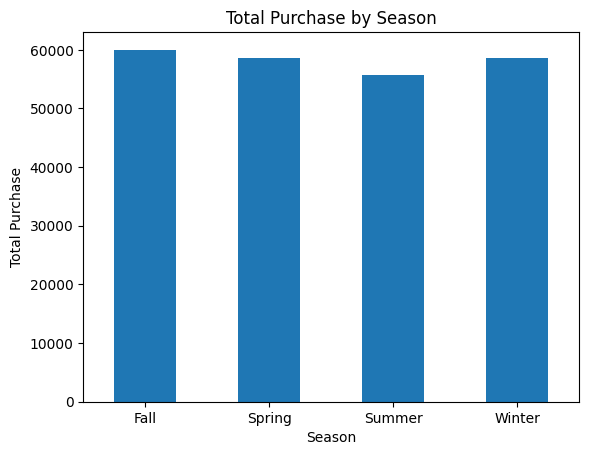

In [22]:
season_purchase = df.groupby('season')['purchase_amount'].sum()

print(season_purchase)

season_purchase.plot(kind='bar')

plt.xlabel('Season')
plt.ylabel('Total Purchase')
plt.title('Total Purchase by Season')
plt.xticks(rotation=0)
plt.show()

In [23]:
df['frequency_of_purchases'].value_counts()

frequency_of_purchases
Every 3 Months    584
Annually          572
Quarterly         563
Monthly           553
Bi-Weekly         547
Fortnightly       542
Weekly            539
Name: count, dtype: int64

In [26]:
purchase_frequency = (df.groupby('frequency_of_purchases')['purchase_amount'].sum()
.sort_values(ascending=False))

print(purchase_frequency)

frequency_of_purchases
Every 3 Months    35088
Annually          34419
Quarterly         33771
Bi-Weekly         33200
Monthly           32810
Fortnightly       32007
Weekly            31786
Name: purchase_amount, dtype: int64


In [35]:
purchase_analysis = (
    df.groupby(['frequency_of_purchases', 'category'])['purchase_amount']
    .sum()
    .reset_index()
)

print(purchase_analysis)

   frequency_of_purchases     category  purchase_amount
0                Annually  Accessories            11230
1                Annually     Clothing            15645
2                Annually     Footwear             5188
3                Annually    Outerwear             2356
4               Bi-Weekly  Accessories            10933
5               Bi-Weekly     Clothing            14788
6               Bi-Weekly     Footwear             4872
7               Bi-Weekly    Outerwear             2607
8          Every 3 Months  Accessories            10680
9          Every 3 Months     Clothing            16118
10         Every 3 Months     Footwear             5524
11         Every 3 Months    Outerwear             2766
12            Fortnightly  Accessories             9877
13            Fortnightly     Clothing            13246
14            Fortnightly     Footwear             5733
15            Fortnightly    Outerwear             3151
16                Monthly  Accessories          

The important part is .reset_index(). It converts the grouped Series into a DataFrame.

In [30]:
import seaborn as sns

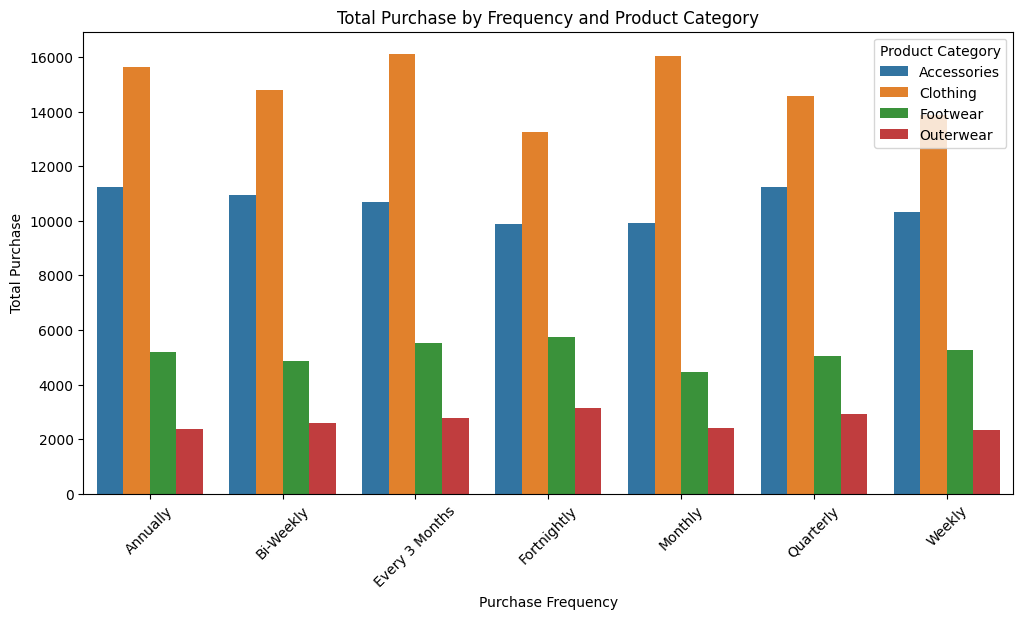

In [37]:
plt.figure(figsize=(12, 6))

sns.barplot(
    data=purchase_analysis,
    x='frequency_of_purchases',
    y='purchase_amount',
    hue='category'
)

plt.xlabel('Purchase Frequency')
plt.ylabel('Total Purchase')
plt.title('Total Purchase by Frequency and Product Category')
plt.xticks(rotation=45)
plt.legend(title='Product Category')
plt.show()

here we can see that every 3 months and monthly purchases are higher in number in cloting .

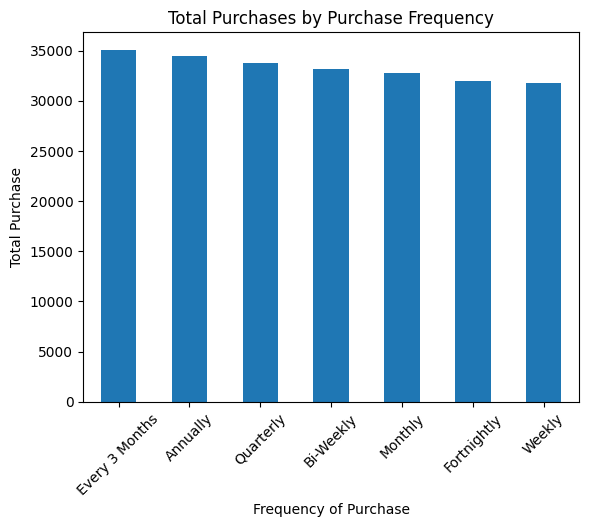

In [28]:
import matplotlib.pyplot as plt

purchase_frequency.plot(kind='bar')

plt.xlabel('Frequency of Purchase')
plt.ylabel('Total Purchase')
plt.title('Total Purchases by Purchase Frequency')
plt.xticks(rotation=45)
plt.show()

Highest Purchases happend in every 3 months in above graph we can see that in every 3 months purchases frequency is higher than other purchases.


Find out total_purchase by age group

In [38]:
age_purchase = (
    df.groupby('age_group')['purchase_amount']
    .sum()
)

print(age_purchase)

age_group
Young Adult    62143
Adult          55978
Middle_aged    59197
Senior         55763
Name: purchase_amount, dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_4568\4097214757.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['purchase_amount']


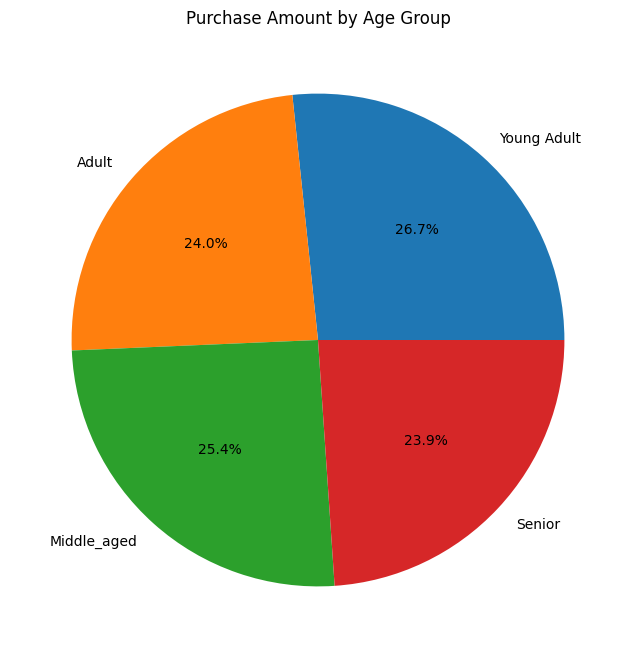

In [39]:
age_purchase.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8, 8)
)

plt.title('Purchase Amount by Age Group')
plt.ylabel('')
plt.show()

In [45]:
age_purchase = (
    df.groupby('age_group')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
)

print(age_purchase)

age_group
Young Adult    62143
Middle_aged    59197
Adult          55978
Senior         55763
Name: purchase_amount, dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_4568\2815155255.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['purchase_amount']


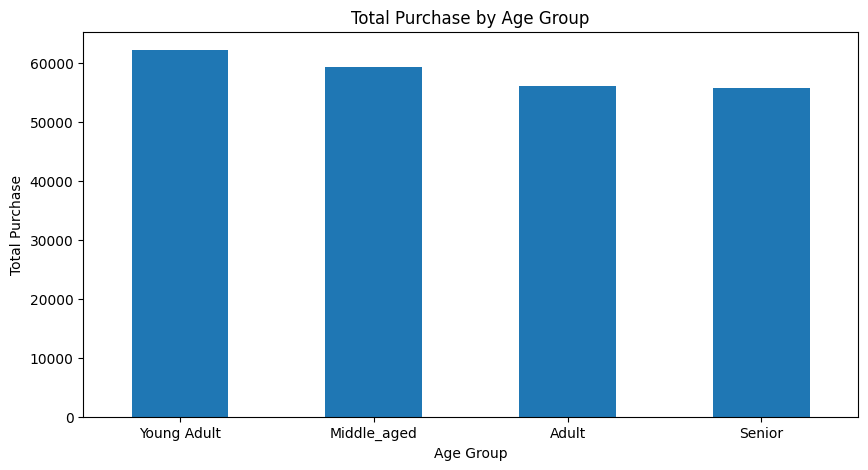

In [46]:

age_purchase.plot(
    kind='bar',
    figsize=(10, 5)
)

plt.xlabel('Age Group')
plt.ylabel('Total Purchase')
plt.title('Total Purchase by Age Group')
plt.xticks(rotation=0)
plt.show()

“The Young Adult age group has the highest total purchase spending among the age groups.”

In [47]:
age_purchase = (
    df.groupby('age_group')['purchase_amount']
    .sum()
    .sort_values(ascending=False)
)

print(age_purchase)

age_group
Young Adult    62143
Middle_aged    59197
Adult          55978
Senior         55763
Name: purchase_amount, dtype: int64


C:\Users\lenovo\AppData\Local\Temp\ipykernel_4568\2815155255.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_group')['purchase_amount']


In [48]:
print(age_purchase.idxmax())

Young Adult


find the which Gender spend more on shopping 

In [5]:
gender_purchases = (
    df.groupby('gender')['purchase_amount']
.sum()
.sort_values(ascending=False)
) 
print(gender_purchases)

gender
Male      157890
Female     75191
Name: purchase_amount, dtype: int64


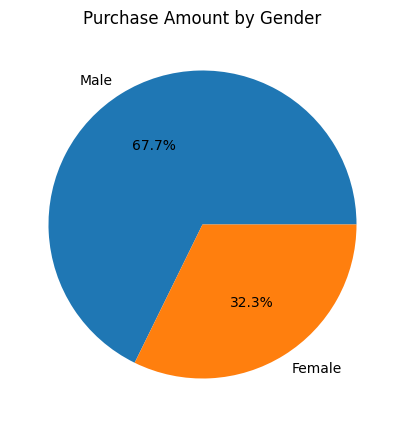

In [9]:
gender_purchases.plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(5, 5)
)

plt.title('Purchase Amount by Gender')
plt.ylabel('')
plt.show()

male is spending more than female.

In [ ]:
! pip install pymysql sqlalchemy

In [53]:
from sqlalchemy import create_engine, text
from sqlalchemy.engine import URL

connection_url = URL.create(
    "mysql+pymysql",
    username="root",
    password="priti@2187",
    host="localhost",
    port=3306,
    database="customer_behaviour"
)

engine = create_engine(connection_url)

with engine.connect() as connection:
    result = connection.execute(text("SELECT DATABASE();"))
    print(result.fetchone())

('customer_behaviour',)


In [54]:
# 3. Load DataFrame into MySQL
df.to_sql(
    name="customer_purchase",
    con=engine,
    if_exists="replace",
    index=False
)

print("Data loaded successfully!")

Data loaded successfully!


### Key Findings

* **Purchase Frequency:** Customers show higher purchase amounts for **quarterly (every 3 months) and annual purchases**, indicating that these purchasing frequencies contribute significantly to overall spending.

* **Product Category:** **Clothing** is the leading product category in terms of customer spending, indicating strong demand for clothing products.

* **Seasonal Behaviour:** Customer purchasing behaviour remains **relatively consistent across seasons**, with no major variation in overall purchase amounts.

* **Age Group Spending:** The **Young Adult** segment contributes the highest share of total purchase amount at **26.7%**, followed by **Middle-aged customers (25.4%)**, **Adults (24.0%)**, and **Seniors (23.9%)**.

* **Total Spending by Age Group:** Young Adults have the highest total spending at **62,143**, followed by Middle-aged customers at **59,197**, Adults at **55,978**, and Seniors at **55,763**.

* **Gender-wise Spending:** **Male customers account for higher total spending than female customers** in the analyzed dataset.




### Overall Insight

The analysis indicates that **Young Adults are the highest-spending customer segment**, while clothing is the leading product category. Quarterly and annual purchasing patterns account for higher purchase amounts, and customer spending remains relatively consistent across seasons. The dataset also shows higher total spending among male customers compared with female customers.